# XGBoost - Diabetes Readmission Prediction

Adrian Balingit, CS 549 Final Project (Spring 2026)

Runs the XGBoost pipeline from `src/xgboost_model.py` and shows the metrics and figures inline.

## Run the pipeline

In [1]:
%pip install seaborn matplotlib 

Note: you may need to restart the kernel to use updated packages.


In [2]:
 %pip install -e .

Obtaining file:///Users/adrianbalingit/ProgrammingWorkspace/Spring26/CS549/FinalProject/diabetes-readmission-risk
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for diabetes-readmission-risk (pyproject.toml) ... done
  Created wheel for diabetes-readmission-risk: filename=diabetes_readmission_risk-0.1.0-0.editable-py3-none-any.whl size=1562 sha256=bc79694fc021ba9c7075c968635ba40fb98b1c7aa0879a1488079ae5d4ddee6f
  Stored in directory: /private/var/folders/hd/cd_4l4pn1_178j5s9tm29yrr0000gn/T/pip-ephem-wheel-cache-ms5w7hyv/wheels/b8/d4/e2/7281e3c107e832146aa7cbc53f3d628934b1f97100ae7d6799
Successfully built diabetes-readmission-risk
  Attempting uninstall: diabetes-readmission-risk
    Found existing installation: diabetes-readmission-risk 0.1.0
    Uninstalling diabetes-readmission-risk-0.1.0:
      Successful

In [3]:
%run src/xgboost_model.py

[16:52:08] XGBoost pipeline started

[16:52:08] [1/5] Loading splits...
  X_train: (101456, 89), y_train balance: {0: 50728, 1: 50728}
  X_test : (13912, 89), y_test  balance: {0: 12682, 1: 1230}
  done in 0.4s

[16:52:08] [2/5] Hyperparameter tuning (5-fold CV, 30 candidates = 150 fits)...
  Running RandomizedSearchCV: 30 candidates x 5-fold CV = 150 fits, scoring=average_precision
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Tuning finished in 67.1s
  Best CV average_precision: 0.9796
  Best params: {
  "subsample": 0.7,
  "reg_lambda": 1.0,
  "reg_alpha": 0.0,
  "n_estimators": 400,
  "min_child_weight": 3,
  "max_depth": 9,
  "learning_rate": 0.05,
  "gamma": 0.0,
  "colsample_bytree": 0.7
}
  done in 67.1s

[16:53:15] [3/5] Final fit on full training set...
  done in 13.3s

[16:53:29] [4/5] Selecting thresholds from test PR curve and evaluating...
  F1-optimal threshold: 0.1459 (F1 = 0.2221, P = 0.1671, R = 0.3309)
  Recall-target threshold (R >= 0.5): 0.1087 (P

## Saved metrics

In [4]:
import json

with open("reports/xgboost_metrics.json") as f:
    metrics = json.load(f)

print(json.dumps(metrics, indent=2))

{
  "model": "XGBoost",
  "cv_folds": 5,
  "search_iterations": 30,
  "tuning_scoring": "average_precision",
  "best_cv_score": 0.9795915112883735,
  "best_params": {
    "subsample": 0.7,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "n_estimators": 400,
    "min_child_weight": 3,
    "max_depth": 9,
    "learning_rate": 0.05,
    "gamma": 0.0,
    "colsample_bytree": 0.7
  },
  "f1_threshold": 0.14593854546546936,
  "recall_target_threshold": 0.10865411907434464,
  "recall_target": 0.5,
  "tuning_runtime_seconds": 67.11364936828613,
  "final_train_runtime_seconds": 13.280453205108643,
  "total_runtime_seconds": 81.30922484397888,
  "test_metrics": {
    "roc_auc": 0.6376026837858665,
    "pr_auc": 0.16836045052197463,
    "default_threshold_0.5": {
      "threshold": 0.5,
      "accuracy": 0.9119465209890741,
      "precision": 0.5490196078431373,
      "recall": 0.022764227642276424,
      "f1": 0.04371584699453552,
      "f2": 0.02816334741500704,
      "confusion_matrix": [
   

## Figures

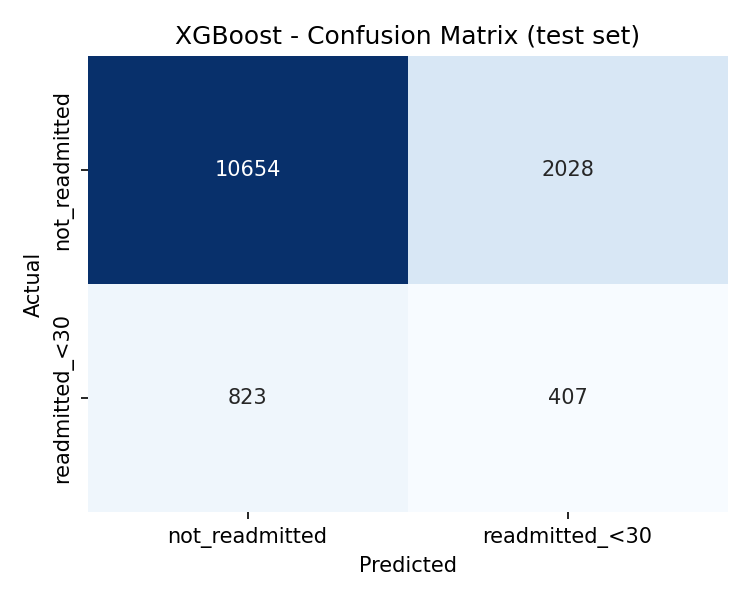

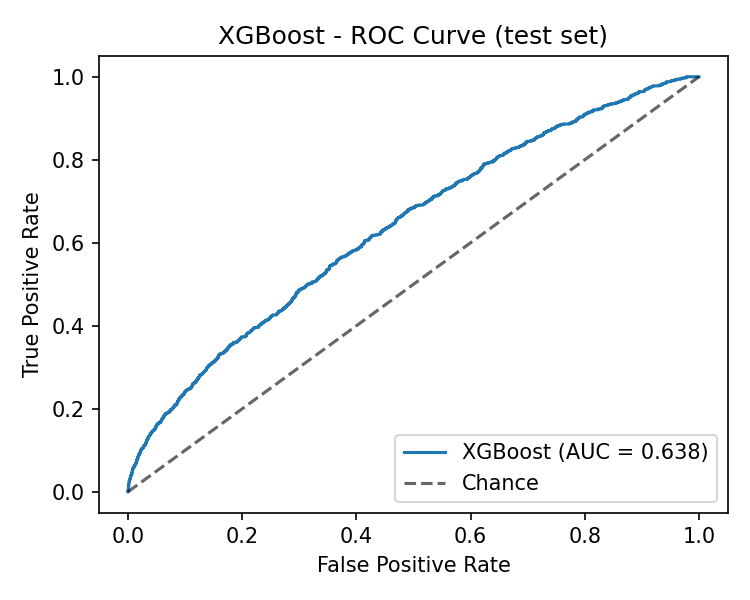

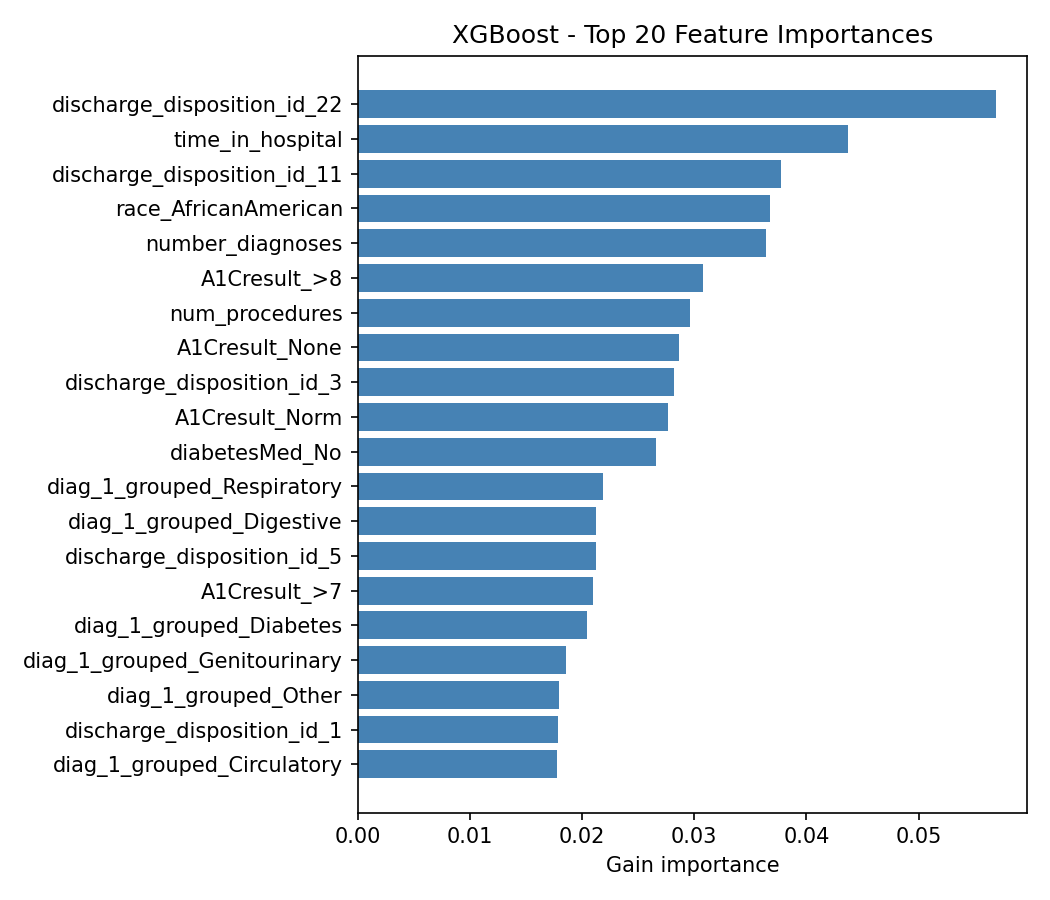

In [5]:
from IPython.display import Image, display

display(Image("reports/xgboost_confusion_matrix.png"))
display(Image("reports/xgboost_roc_curve.png"))
display(Image("reports/xgboost_feature_importance.png"))